In [3]:
import os

import numpy as np
import pandas as pd


for dirname, _, filenames in os.walk("data"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data\gender_submission.csv
data\test.csv
data\train.csv


In [4]:
train_data = pd.read_csv("data/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_data = pd.read_csv("data/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = (sum(women)/len(women)) * 100

print("% of women who survived:", rate_women)

men = train_data.loc[train_data.Sex == "male"]["Survived"]
rate_men = (sum(men)/len(men)) * 100

print("% of men who survived", rate_men)

% of women who survived: 74.20382165605095
% of men who survived 18.890814558058924


In [ ]:
from sklearn.ensemble import RandomForestClassifier


y = train_data["Survived"]

features = ["Pclass", "Sex", "SibSp", "Parch", "Fare"]
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X, y)
predictions = model.predict(X_test)

output = pd.DataFrame(
    {"PassengerId": test_data.PassengerId, "Survived": predictions},
)
output.to_csv('output_forest.csv', index=False)


In [ ]:
output_data = pd.read_csv("output_forest.csv")

total = output_data["Survived"]
dead = output_data.loc[output_data.Survived == 0]["Survived"]
survived = output_data.loc[output_data.Survived == 1]["Survived"]

print(dead)

rate_survived = (len(survived)/len(total)) * 100
rate_dead = (len(dead)/len(total)) * 100

print("% of survivors:", rate_survived)
print("% of deaths:", rate_dead)

print("Model Score:", model.score(X, y))

0      0
2      0
3      0
5      0
7      0
      ..
407    0
413    0
415    0
416    0
417    0
Name: Survived, Length: 273, dtype: int64
% of survivors: 34.688995215311
% of deaths: 65.311004784689
Model Score: 0.8226711560044894


In [ ]:
from sklearn.tree import DecisionTreeClassifier


y = train_data["Survived"]

features = ["Pclass", "Sex", "SibSp", "Parch", "Fare"]
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

model_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=1,
)
model_tree.fit(X, y)
predictions_tree = model_tree.predict(X_test)

output2 = pd.DataFrame(
    {"PassengerId": test_data.PassengerId, "Survived": predictions_tree},
)
output2.to_csv('output_dtree.csv', index=False)

In [ ]:
output_data = pd.read_csv("output_dtree.csv")

total = output_data["Survived"]
dead = output_data.loc[output_data.Survived == 0]["Survived"]
survived = output_data.loc[output_data.Survived == 1]["Survived"]

print(dead)

rate_survived = (len(survived)/len(total)) * 100
rate_dead = (len(dead)/len(total)) * 100

print("% of survivors:", rate_survived)
print("% of deaths:", rate_dead)

print("Model Score:", model_tree.score(X, y))

0      0
2      0
3      0
4      0
5      0
      ..
409    0
413    0
415    0
416    0
417    0
Name: Survived, Length: 287, dtype: int64
% of survivors: 31.33971291866029
% of deaths: 68.6602870813397
Model Score: 0.8372615039281706


In [ ]:
import re

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
)


features = ["Pclass", "Age", "Sex", "Name", "SibSp", "Parch", "Fare"]
num_features = ["Pclass"]
cat_features = ["Sex"]
title_features = ["Name"]
family_features = ["SibSp", "Parch"]
child_features = ["Age"]
fare_features = ["Fare"]
deck_features = ["Cabin"]

def extract_titles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract the titles from the names of passengers.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to extract names from.

    Returns
    -------
    pd.DataFrame
        The dataframe containing the extracted titles.

    """
    copy = df.copy()
    names = copy["Name"]
    titles = names.str.extract(r' ([A-Za-z]+)\.', expand=False)

    misc = [
        title
        for title in titles
        if title not in ["Ms", "Mrs", "Miss", "Mr", "Master"]
    ]

    titles = titles.replace("Ms", "Miss")
    titles = titles.replace(misc, "Misc")

    return pd.DataFrame(titles)


def create_family(df: pd.DataFrame) -> pd.DataFrame:
    """
    Function to create two new columns relating to sizes of family and aloneness.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to copy and create family columns from.

    Returns
    -------
    pd.DataFrame
        The dataframe containing the newly calculated family columns.

    """
    copy = df.copy()

    copy["FamilySize"] = copy["SibSp"] + copy["Parch"] + 1

    copy["IsAlone"] = 0
    copy.loc[copy["FamilySize"] == 1, "IsAlone"] = 1

    return copy[["FamilySize", "IsAlone"]]


def child_priority(df: pd.DataFrame) -> pd.DataFrame:
    """
    Function to create a new column to identify if the passenger is a child or not.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to copy and create child column from.

    Returns
    -------
    pd.DataFrame
        The dataframe containing the newly created child column.

    """
    copy = df.copy()

    copy["IsChild"] = (copy["Age"] < 16).astype(int)

    return copy[["IsChild"]]


def extract_decks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract the decks from the names of passenger's cabins.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to extract decks from.

    Returns
    -------
    pd.DataFrame
        The dataframe containing the extracted decks.

    """
    copy = df.copy()
    names = copy["Cabin"]
    decks = names.str.extract(r'^([A-Z])', expand=False)

    decks = decks.fillna('X')

    print(pd.DataFrame(decks))

    return pd.DataFrame(decks)


X_train = train_data[features]
y_train = train_data["Survived"]
X_test = test_data[features]

params = {
    'l2_regularization': 0.5,
    'learning_rate': 0.2,
    'max_depth': 8,
    'max_iter': 50,
}

classifier = HistGradientBoostingClassifier(**params)

num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ],
)
cat_transformer = OneHotEncoder(handle_unknown="ignore")

title_transformer = Pipeline(
    steps=[
        ("extractor", FunctionTransformer(extract_titles)),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ],
)

family_transformer = FunctionTransformer(create_family)

child_transformer = Pipeline(
    steps=[
        ("extractor", FunctionTransformer(child_priority)),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ],
)

fare_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("logging", FunctionTransformer(np.log1p)),
    ],
)

deck_transformer = Pipeline(
    steps=[
        ("extractor", FunctionTransformer(extract_decks)),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ],
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
        ("title", title_transformer, title_features),
        #("family", family_transformer, family_features),
        #("child", child_transformer, child_features),
        ("fare", fare_transformer, fare_features),
        # ("deck", deck_transformer, deck_features),
    ],
)

model_make = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ],
)

model_make.fit(X_train, y_train)
make_prediction = model_make.predict(X_test)

output_make = pd.DataFrame(
    {"PassengerId": test_data.PassengerId, "Survived": make_prediction},
)
output_make.to_csv('output_make.csv', index=False)

read_make = pd.read_csv("output_make.csv")

total_make = read_make["Survived"]
dead_make = read_make.loc[read_make.Survived == 0]["Survived"]
survived_make = read_make.loc[read_make.Survived == 1]["Survived"]

survived_make = (len(survived_make)/len(total_make)) * 100
dead_make = (len(dead_make)/len(total_make)) * 100

print("% of survivors:", survived_make)
print("% of deaths:", dead_make)

scores = cross_val_score(model_make, X_train, y_train, cv=5)

print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

% of survivors: 30.62200956937799
% of deaths: 69.377990430622
Average Accuracy: 0.8507375557089951
Standard Deviation: 0.025962300911761754


In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_iter': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [1, 2, 3, 4, 5, 8, 10, 15, 20, 30, 50, None],
    'classifier__l2_regularization': [0, 0.1, 0.5, 1.0, 1.5, 2.0]
}

grid_search = GridSearchCV(model_make, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

Best Params: {'classifier__l2_regularization': 0.5, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 8, 'classifier__max_iter': 50}
Best Score: 0.8507375557089951


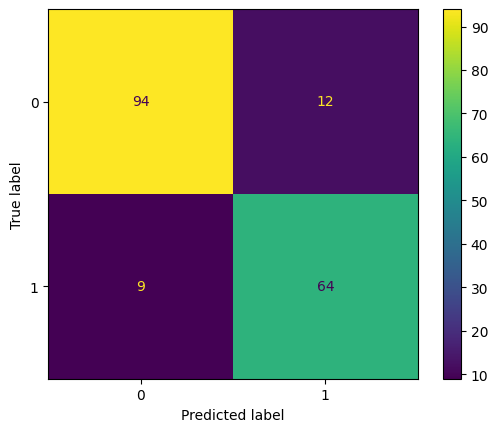

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Split your training data into a "mini-train" and a "validation" set
X_train_mini, X_val, y_train_mini, y_val = train_test_split(X_train, y_train, test_size=0.2)

# Using a validation split as we discussed before
y_pred = model_make.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [34]:
import joblib

joblib.dump(model_make, 'titanic_survival_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [37]:
joblib.dump(grid_search, 'grid_search_model.pkl')

print("Model saved successfully!")

Model saved successfully!
